In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score,classification_report,roc_auc_score,confusion_matrix

In [26]:
# Load Dataset
df = pd.read_csv(r"C:\Users\User\Downloads\Git Folder\PROJECT II\Customer-Churn dataset.csv");
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Data Cleaning
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
df.shape

(7043, 21)

In [7]:
df.drop("customerID",axis =1,inplace = True)

In [8]:
# Convert TotalCharges to Numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors = "coerce")


In [9]:
# Fill Missing Values
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

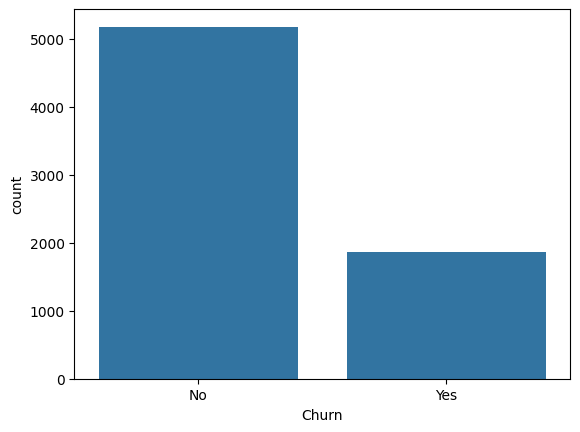

In [10]:
# Churn Distribution
sns.countplot(x="Churn", data=df)
plt.show()

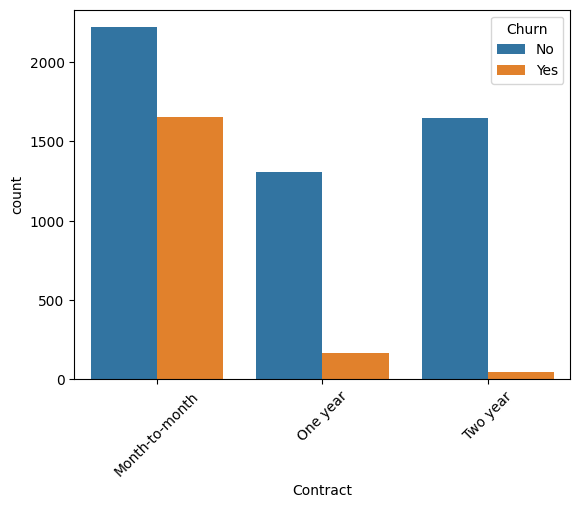

In [11]:
# Contract Type vs Churn
sns.countplot( x="Contract", hue = "Churn",data=df)
plt.xticks(rotation=45)
plt.show()

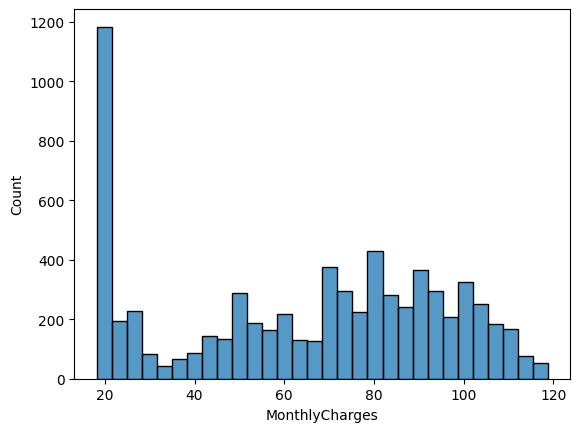

In [12]:
# Monthly Charges Distribution
sns.histplot(df["MonthlyCharges"],bins = 30)
plt.show()

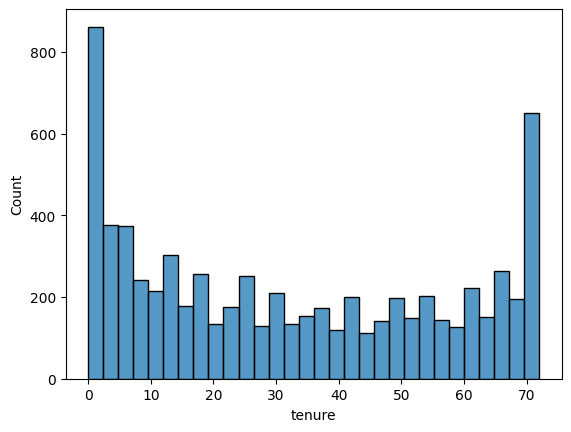

In [13]:
# Tenure Distribution
sns.histplot(df["tenure"],bins = 30)
plt.show()

In [14]:
# Encode Categorical Features
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col])

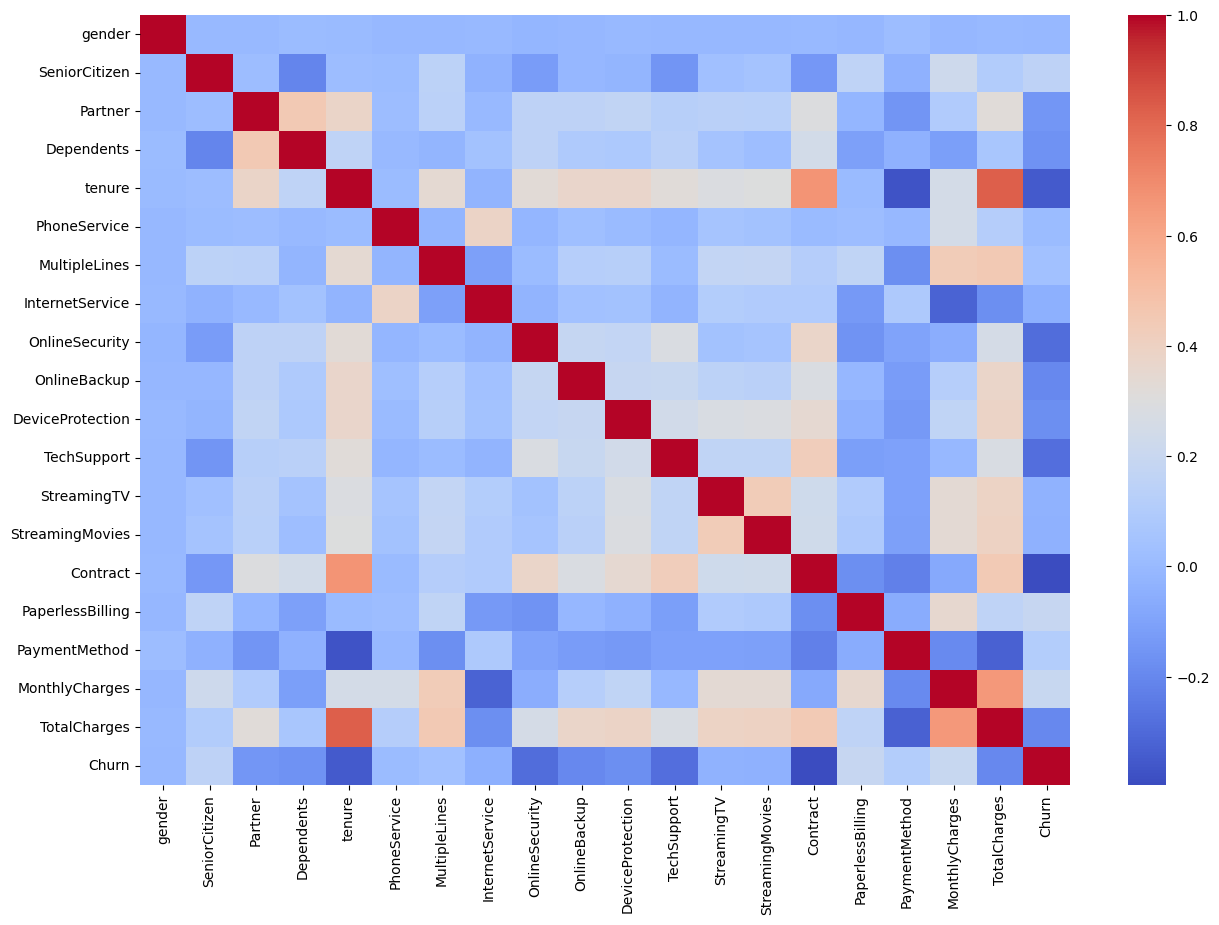

In [15]:
# Correlation Heatmap
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.show()

In [ ]:
x = df.drop("Churn",axis = 1)
y = df["Churn"]

x_train,x_test,y_train,y_test = train_test_split( x,y,test_size=0.2,random_state = 42, stratify=y )


In [17]:
scaler = StandardScaler()

X_train = scaler.fit_transform(x_train)
X_test = scaler.transform(x_test)

In [18]:
lr = LogisticRegression(max_iter = 1000)

lr.fit(X_train,y_train)
pred_lr = lr.predict(X_test)

print("Accuracy Score :", accuracy_score(y_test,pred_lr))

Accuracy Score : 0.7991483321504613


In [19]:
dt = DecisionTreeClassifier( random_state = 42)

dt.fit(X_train,y_train)
pred_dt = dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test,pred_dt))

Accuracy: 0.7295954577714692


In [20]:
rf = RandomForestClassifier(
    n_estimators=200,random_state =42)

rf.fit(X_train,y_train)
pred_rf = rf.predict(X_test)

print("Accuracy:",accuracy_score(y_test,pred_rf))

Accuracy: 0.7877927608232789


In [21]:
# Compare Models
result = pd.DataFrame({
    "Model":[
        "Logistic Regression","Decision Tree ","Random Forest"
    ],
    "Accuracy":[
        accuracy_score(y_test,pred_lr),
        accuracy_score(y_test,pred_dt),
        accuracy_score(y_test,pred_rf)
    ]
})
result.sort_values(
    by="Accuracy", ascending =False )

,Model,Accuracy
0,Logistic Regression,0.799148
2,Random Forest,0.787793
1,Decision Tree,0.729595


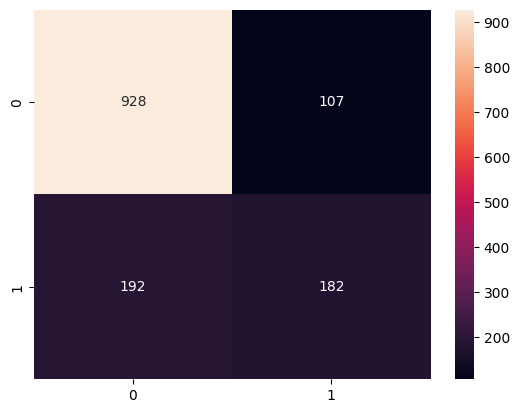

In [22]:
cm = confusion_matrix(y_test,pred_rf)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)
plt.show()

In [23]:
print(classification_report(y_test,pred_rf))

prob = rf.predict_proba(X_test)[:,1]

print(roc_auc_score(y_test,prob))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.63      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409

0.8246790152160995


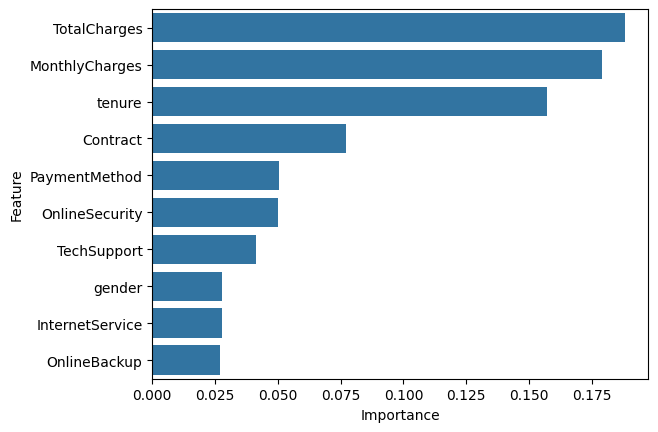

In [24]:
# Feature Importance
importance = pd.DataFrame({
    "Feature":x.columns,
    "Importance":rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance.head(10)
)

plt.show()

In [25]:
import joblib

joblib.dump(lr, "churn_model.pkl")

['churn_model.pkl']